# 02. Exploratory analysis and statistical tests

**Objective.** Find out which applicant characteristics are associated with default, and how strongly.

**Business question.** Which customer and loan characteristics go with higher observed default, and are those differences large enough to matter?

**Why this analysis is needed.** It decides which relationships a model must be able to represent (for example, whether debt burden acts in a straight line) and gives every later model result something to be checked against.

**Rules followed here.**
- Only the **training split** (60% of applicants) is used. The validation and test splits are not opened, so nothing learned here can leak into their scores.
- Every chart answers one question. Differences are associations, not causes.
- Statistical tests are reported together with an effect size, because with about 185,000 rows even trivial differences are "significant".

*Educational project. Not a lending policy.*

In [1]:
import sys
sys.path.append("..")

import pandas as pd

from src.analysis import add_missing_category, chi_square_test, default_rate_table, mann_whitney_auc
from src.data import load_modelling_table
from src.plots import apply_style, default_rate_chart

apply_style()
table = load_modelling_table()
train = table[table["split"] == "train"]
target = train["TARGET"]
base_rate = target.mean()
print("training rows:", len(train), "| default rate:", f"{base_rate:.2%}")
print("splits present in the table:", table["split"].value_counts().to_dict())

training rows: 184506 | default rate: 8.07%
splits present in the table: {'train': 184506, 'test': 61503, 'valid': 61502}


## Reading the charts and tests

**Charts.** Bars show the default rate in each group; the whiskers are 95% Wilson confidence intervals; the dashed line is the overall training rate (8.07%). Group size is printed under each label.

**Chi-square test of independence** (used for categories). H0: default rate is the same in every group. H1: at least one group differs. It fits because the outcome and the grouping are both categorical and every group is large. Groups under 1,000 applicants are excluded from the test, since their expected counts are too small to trust. Effect size is Cramér's V (0 = no association, 1 = perfect; below about 0.1 is small).

**Mann-Whitney U test** (used for numeric features). H0: a defaulter and a non-defaulter are equally likely to have the higher value. H1: one is more likely to. It fits because it needs no normality assumption, and several variables here are heavily skewed. Effect size is the AUC form: 0.5 means no ranking power, values below 0.5 mean defaulters tend to have lower values, and 1 minus the value is the discriminating power in the other direction.

**Limits that apply to all of them.** The tests assume independent rows (one row per applicant, so that holds). A rank test only detects consistent direction, so a relationship that rises and falls can be missed, as shown in section 2.

## 1. Does default differ by product and by income source?

**Why:** these are the first cuts a credit analyst would make, and they show which segments already look different before any model exists.

          group      n   rate    low   high
     Cash loans 166910 0.0835 0.0822 0.0848
Revolving loans  17596 0.0547 0.0515 0.0582
{'chi2': np.float64(176.80315652363936), 'dof': 1, 'p_value': np.float64(2.417991957748567e-40), 'cramers_v': np.float64(0.030955638073438298)}

{'chi2': np.float64(706.1396167404016), 'dof': 3, 'p_value': np.float64(9.78880266741499e-153), 'cramers_v': np.float64(0.06186865059104013)}

                        group      n   rate
             Higher education  44914 0.0538
            Incomplete higher   6224 0.0914
              Lower secondary   2268 0.1107
Secondary / secondary special 131010 0.0890
{'chi2': np.float64(594.172183717622), 'dof': 3, 'p_value': np.float64(1.8483106352731397e-128), 'cramers_v': np.float64(0.05676189150404585)}


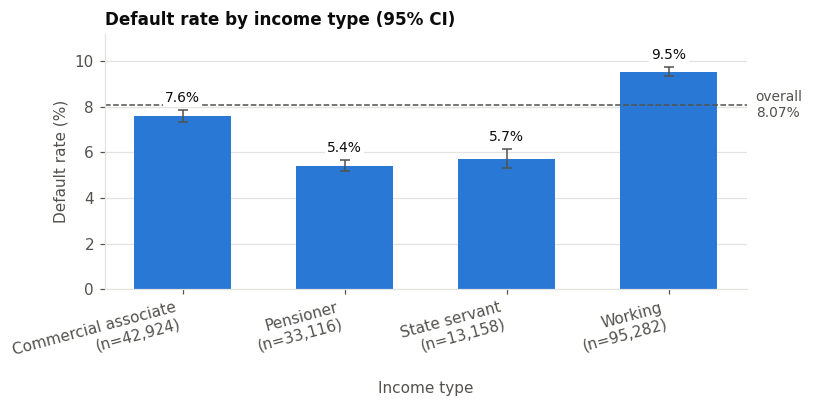

In [2]:
contract = default_rate_table(target, train["NAME_CONTRACT_TYPE"])
print(contract[["group", "n", "rate", "low", "high"]].round(4).to_string(index=False))
print(chi_square_test(target, train["NAME_CONTRACT_TYPE"]))

large_income = train.groupby("NAME_INCOME_TYPE")["TARGET"].transform("size") >= 1000
income = default_rate_table(target[large_income], train.loc[large_income, "NAME_INCOME_TYPE"])
print()
print(chi_square_test(target[large_income], train.loc[large_income, "NAME_INCOME_TYPE"]))
fig = default_rate_chart(income, "Default rate by income type (95% CI)", "Income type", base_rate, rotate=15)

large_edu = train.groupby("NAME_EDUCATION_TYPE")["TARGET"].transform("size") >= 1000
education = default_rate_table(target[large_edu], train.loc[large_edu, "NAME_EDUCATION_TYPE"])
print()
print(education[["group", "n", "rate"]].round(4).to_string(index=False))
print(chi_square_test(target[large_edu], train.loc[large_edu, "NAME_EDUCATION_TYPE"]))

**Observation.**
- Cash loans default at 8.35% against 5.47% for revolving loans (chi-square 176.8, p about 2e-40, Cramér's V 0.031).
- By income type, working applicants default at 9.54%, commercial associates at 7.59%, state servants at 5.72% and pensioners at 5.41% (chi-square 706.1, V 0.062).
- By education, the rate falls from 11.07% (lower secondary, only 2,268 applicants) and about 9% (secondary and incomplete higher) to 5.38% (higher education) (chi-square 594.2, V 0.057).

**Interpretation.** Every difference is statistically overwhelming and every effect size is small: Cramér's V stays between 0.03 and 0.06, and the gaps are three to six percentage points. These variables help rank applicants a little but no one of them separates risk. The low pensioner rate may partly reflect age (older applicants default less, see section 4), and the two cannot be separated here, so it is not read as a causal effect of being a pensioner.

**Decision.** Keep all three variables as features. The very small categories excluded from the tests stay in the data.

## 2. Does a heavier debt burden mean higher default?

**Question (hypothesis H1):** applicants whose loan is large relative to their income, or whose repayment is a large share of it, default more.

**Why it matters:** this is the central affordability assumption in retail lending, and it should be checked, not assumed.

     group     n   rate
 Q1 lowest 36921 0.0725
        Q2 36887 0.0878
        Q3 36910 0.0892
        Q4 36898 0.0818
Q5 highest 36890 0.0725
Mann-Whitney: {'auc': np.float64(0.4973163746851347), 'p_value': np.float64(0.27667577469690197), 'n': 184506}

     group     n   rate
 Q1 lowest 36906 0.0717
        Q2 36893 0.0783
        Q3 36900 0.0824
        Q4 36911 0.0860
Q5 highest 36888 0.0853
   Missing     8 0.0000
Mann-Whitney: {'auc': np.float64(0.5196081352131896), 'p_value': np.float64(1.8928183911046255e-15), 'n': 184498}


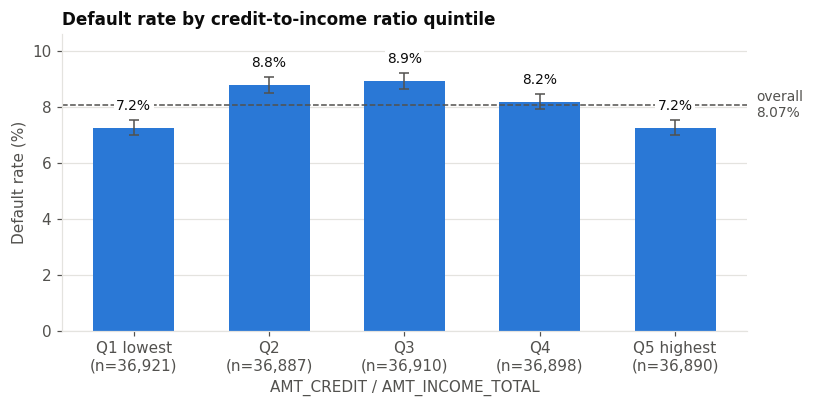

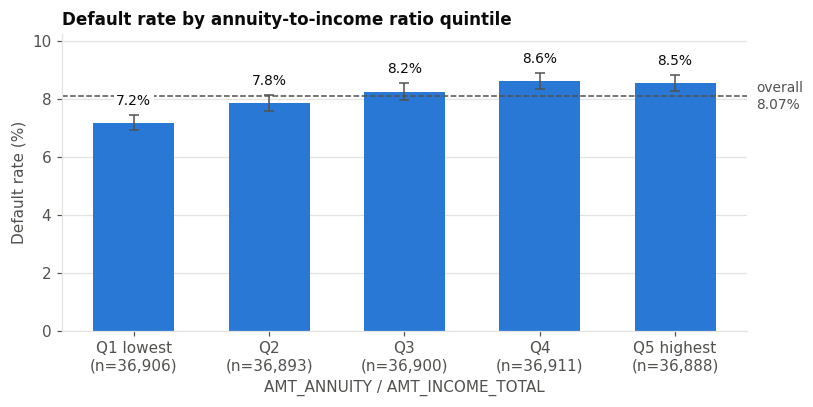

In [3]:
labels = ["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"]

credit_income = add_missing_category(pd.qcut(train["CREDIT_INCOME_RATIO"], 5, labels=labels))
credit_summary = default_rate_table(target, credit_income)
print(credit_summary[["group", "n", "rate"]].round(4).to_string(index=False))
print("Mann-Whitney:", mann_whitney_auc(train["CREDIT_INCOME_RATIO"], target))
fig = default_rate_chart(credit_summary, "Default rate by credit-to-income ratio quintile", "AMT_CREDIT / AMT_INCOME_TOTAL", base_rate)

annuity_income = add_missing_category(pd.qcut(train["ANNUITY_INCOME_RATIO"], 5, labels=labels))
annuity_summary = default_rate_table(target, annuity_income)
print()
print(annuity_summary[["group", "n", "rate"]].round(4).to_string(index=False))
print("Mann-Whitney:", mann_whitney_auc(train["ANNUITY_INCOME_RATIO"], target))
fig = default_rate_chart(annuity_summary[annuity_summary["n"] > 100], "Default rate by annuity-to-income ratio quintile", "AMT_ANNUITY / AMT_INCOME_TOTAL", base_rate)

**Observation.**
- Credit-to-income follows an inverted U: 7.25% in the lowest quintile, 8.78%, 8.92% and 8.18% in the middle, and 7.25% again in the highest. The Mann-Whitney AUC is 0.497 (p = 0.28), which looks like "no relationship".
- Annuity-to-income rises gently from 7.17% to 8.60% and then flattens at 8.53%. The AUC is 0.520 (p about 2e-15), a real but weak monotonic signal.
- Eight applicants have no annuity and are left out of the second chart.

**Interpretation.** H1 is only weakly supported. The rank test on credit-to-income reports "nothing" because the pattern goes up and then down, not because there is no pattern: the gap between the middle and the ends is about 1.7 percentage points. One possible reason is selection: applicants approved with a very high ratio may have been screened more strictly. That is a hypothesis, not something this table tests.

**Decision.**
- Do not assume debt burden acts in a straight line. Tree models can represent the hump; for logistic regression, binning or a spline will be tried in Phase 6.
- A single-variable rank statistic can hide a real relationship, so features will not be dropped on it alone (decision log D15).

## 3. How strong are the external scores?

**Question:** the three `EXT_SOURCE` columns are described only as "normalized score from external data source". Do they track default, and how much of the population lacks them?

EXT_SOURCE_1 | Mann-Whitney AUC: 0.332
     group      n   rate
 Q1 lowest  16130 0.1466
        Q2  16129 0.0869
        Q3  16130 0.0624
        Q4  16129 0.0469
Q5 highest  16130 0.0300
   Missing 103858 0.0855

EXT_SOURCE_2 | Mann-Whitney AUC: 0.345
     group     n   rate
 Q1 lowest 36824 0.1510
        Q2 36824 0.0925
        Q3 36822 0.0699
        Q4 36827 0.0541
Q5 highest 36818 0.0362
   Missing   391 0.0767

EXT_SOURCE_3 | Mann-Whitney AUC: 0.319
     group     n   rate
 Q1 lowest 29894 0.1633
        Q2 29507 0.0888
        Q3 29887 0.0569
        Q4 29720 0.0448
Q5 highest 28900 0.0334
   Missing 36598 0.0928



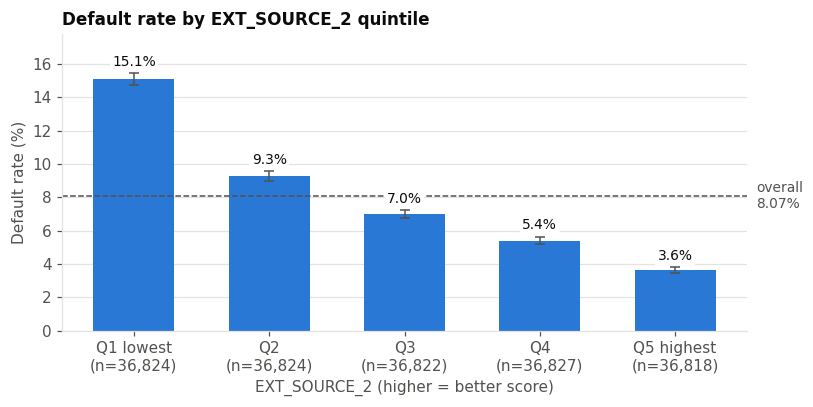

In [4]:
for column in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    groups = add_missing_category(pd.qcut(train[column], 5, labels=labels))
    summary = default_rate_table(target, groups)
    print(column, "| Mann-Whitney AUC:", round(mann_whitney_auc(train[column], target)["auc"], 3))
    print(summary[["group", "n", "rate"]].round(4).to_string(index=False))
    print()

groups = add_missing_category(pd.qcut(train["EXT_SOURCE_2"], 5, labels=labels))
summary = default_rate_table(target, groups)
fig = default_rate_chart(summary[summary["n"] > 1000], "Default rate by EXT_SOURCE_2 quintile", "EXT_SOURCE_2 (higher = better score)", base_rate)

**Observation.** All three scores show a clean, steady fall in default from the lowest to the highest quintile: for `EXT_SOURCE_1` from 14.66% to 3.00%, for `EXT_SOURCE_2` from 15.10% to 3.62%, and for `EXT_SOURCE_3` from 16.33% to 3.34%. The Mann-Whitney AUCs of 0.332, 0.345 and 0.319 mean each score alone ranks defaulters correctly about 67%, 65% and 68% of the time. Missing values are common for `EXT_SOURCE_1` (103,858 of 184,506 rows, default 8.55%, about the average) and `EXT_SOURCE_3` (36,598 rows, default 9.28%, above average).

**Interpretation.** These are by a wide margin the strongest single variables seen so far. Two cautions follow. Nobody can type an external score into an underwriting form, and the provenance is not documented. So a model may lean on them heavily (hypothesis H2), and the app's individual-loan tool has to decide how to treat them.

**Decision.**
- Keep them; the data owner describes them as application-time scores.
- In Phase 6, fit with and without them to measure how much of the model's power they carry (this also informs the simulator design in the architecture notes).

## 4. Age and employment length

**Question:** do younger applicants and those with shorter employment default more, and is the pattern smooth?

group     n   rate
20-29 27309 0.1154
30-39 49359 0.0954
40-49 45809 0.0770
50-59 40871 0.0604
60-69 21158 0.0493
Mann-Whitney AUC: 0.416

  group     n   rate
     <1 16685 0.1087
    1-3 36879 0.1103
    3-5 28252 0.0968
   5-10 38904 0.0751
    10+ 30664 0.0510
Missing 33122 0.0541
Mann-Whitney AUC: 0.418


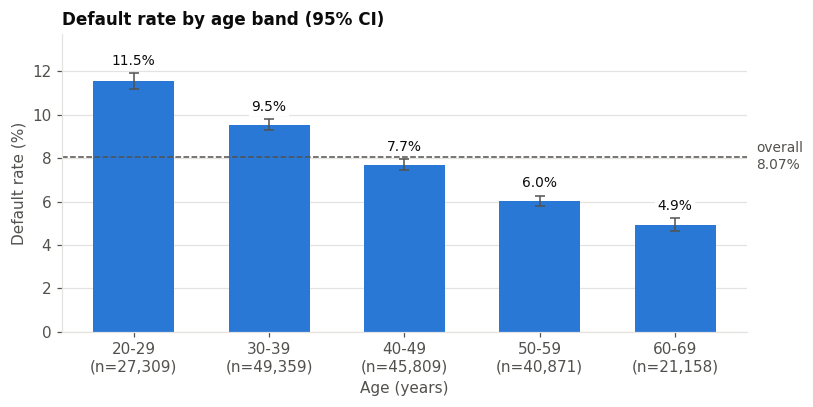

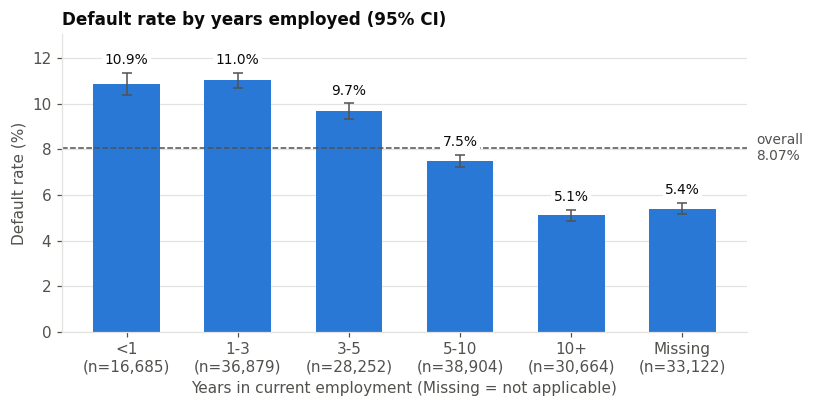

In [5]:
age = pd.cut(train["AGE_YEARS"], [20, 30, 40, 50, 60, 70], right=False,
             labels=["20-29", "30-39", "40-49", "50-59", "60-69"])
age_summary = default_rate_table(target, age)
print(age_summary[["group", "n", "rate"]].round(4).to_string(index=False))
print("Mann-Whitney AUC:", round(mann_whitney_auc(train["AGE_YEARS"], target)["auc"], 3))
fig = default_rate_chart(age_summary, "Default rate by age band (95% CI)", "Age (years)", base_rate)

years_employed = -train["DAYS_EMPLOYED"] / 365.25
employment = pd.cut(years_employed, [0, 1, 3, 5, 10, 50], right=False,
                    labels=["<1", "1-3", "3-5", "5-10", "10+"])
employment = add_missing_category(employment)
employment_summary = default_rate_table(target, employment)
print()
print(employment_summary[["group", "n", "rate"]].round(4).to_string(index=False))
print("Mann-Whitney AUC:", round(mann_whitney_auc(years_employed, target)["auc"], 3))
fig = default_rate_chart(employment_summary, "Default rate by years employed (95% CI)", "Years in current employment (Missing = not applicable)", base_rate)

**Observation.**
- Default falls steadily with age, from 11.54% at 20-29 to 4.93% at 60-69 (AUC 0.416, p about 6e-257; discriminating power 0.584 in the other direction).
- By employment length, default is 10.87% under one year and 11.03% for one to three years, then falls through 9.68% and 7.51% to 5.10% at ten years or more (AUC 0.418). The "Missing" group (33,122 applicants) is the pensioner placeholder from notebook 01 and defaults at 5.41%.

**Interpretation.** Both are strong and monotonic, and they move together (older applicants have been employed longer), so their separate contributions cannot be read from these tables. The first two employment bands are almost equal, so the relationship is flat and then falls, not linear.

**Decision.** Keep both. Age is a sensitive attribute in credit decisions. Whether the model may use it, and what the segment analysis shows across age groups, is deferred to Phases 6 and 8 and is not settled here.

## Summary of tests

| Test | Result | Effect size | Reading |
|---|---|---|---|
| Contract type (chi-square) | p about 2e-40 | V = 0.031 | Significant, small |
| Income type (chi-square) | p about 1e-152 | V = 0.062 | Significant, small |
| Education (chi-square) | p about 2e-128 | V = 0.057 | Significant, small |
| Credit-to-income (Mann-Whitney) | p = 0.28 | AUC 0.497 | Not significant, but the pattern is non-monotonic |
| Annuity-to-income (Mann-Whitney) | p about 2e-15 | AUC 0.520 | Significant, weak |
| External scores 1-3 (Mann-Whitney) | p about 0 | AUC 0.332 / 0.345 / 0.319 | Strong |
| Age (Mann-Whitney) | p about 6e-257 | AUC 0.416 | Significant, moderate |
| Years employed (Mann-Whitney) | p about 4e-211 | AUC 0.418 | Significant, moderate |

Ten tests were run. Correcting for that (a Bonferroni threshold of 0.005) changes no conclusion: all but the credit-to-income test are far below it.

## Decisions from this notebook

| Finding | Decision |
|---|---|
| Category differences are significant but small (V 0.03-0.06) | Keep as features; do not oversell them |
| Credit-to-income rises and then falls | Do not assume linear effects; test binning or splines for logistic regression |
| A rank statistic missed that pattern | Never drop a feature on a single-variable AUC alone |
| External scores are far stronger than anything else | Measure the model with and without them in Phase 6 |
| Age and employment overlap; age is sensitive | Defer the modelling and fairness treatment to Phases 6 and 8 |

## Next step

Notebook 03 defines the engineered features and the history features from the bureau, previous-application and instalment tables, checks their timing, and looks at how much signal each carries.